In [1]:
import warnings
import os
from pathlib import Path
import json
import hydra
import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf
from tslearn.datasets import UCR_UEA_datasets
from src.model.moment import Moment
from src.trainer.moment_trainer import MomentTrainer

from sklearn.metrics import classification_report

from src.processing import LSSTProcessor
from src.utils.init_utils import set_random_seed, setup_saving_and_logging

warnings.filterwarnings("ignore", category=UserWarning)
device = 'mps'
df = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = df.load_dataset("LSST")
processor = LSSTProcessor()
X_train, y_train = processor.fit_transform(X_train, y_train)
X_test, y_test = processor.transform(X_test, y_test)

model = Moment(device=device)

    

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tslearn.datasets import UCR_UEA_datasets
from src.processing import LSSTProcessor
from sklearn.metrics import classification_report

In [18]:
# Load the LSST dataset from UEA archive
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [19]:
tssprocesser = LSSTProcessor()
X_train, y_train = tssprocesser.fit_transform(X_train, y_train)
X_test, y_test = tssprocesser.transform(X_test, y_test)

In [26]:
def plot_lsst_channels(data, labels, obj_index, train_set=True):
    filters = ['u', 'g', 'r', 'i', 'z', 'y']
    colors = ['purple', 'blue', 'green', 'orange', 'red', 'darkred']
    
    object_data = data[obj_index] 

    seq_length = object_data.shape[0]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
    fig.suptitle(f"{'Train' if train_set else 'Test'} Sample with label {labels[obj_index]}", fontsize=16)
    
    axes = axes.flatten()  # Превращаем матрицу 2x3 в плоский список из 6 элементов
    
    for i in range(6):
        ax = axes[i]
        ax.plot(range(seq_length), object_data[:, i], 
                color=colors[i], 
                marker='o', 
                markersize=4, 
                linestyle='-')
        
        ax.set_title(f"Filter {filters[i]}")
        ax.grid(True, alpha=0.3)
        
        # Добавляем подписи осей только для крайних графиков
        if i >= 3: ax.set_xlabel("Timesteps")
        if i % 3 == 0: ax.set_ylabel("Flux")
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Чтобы заголовок не налезал на графики
    plt.show()

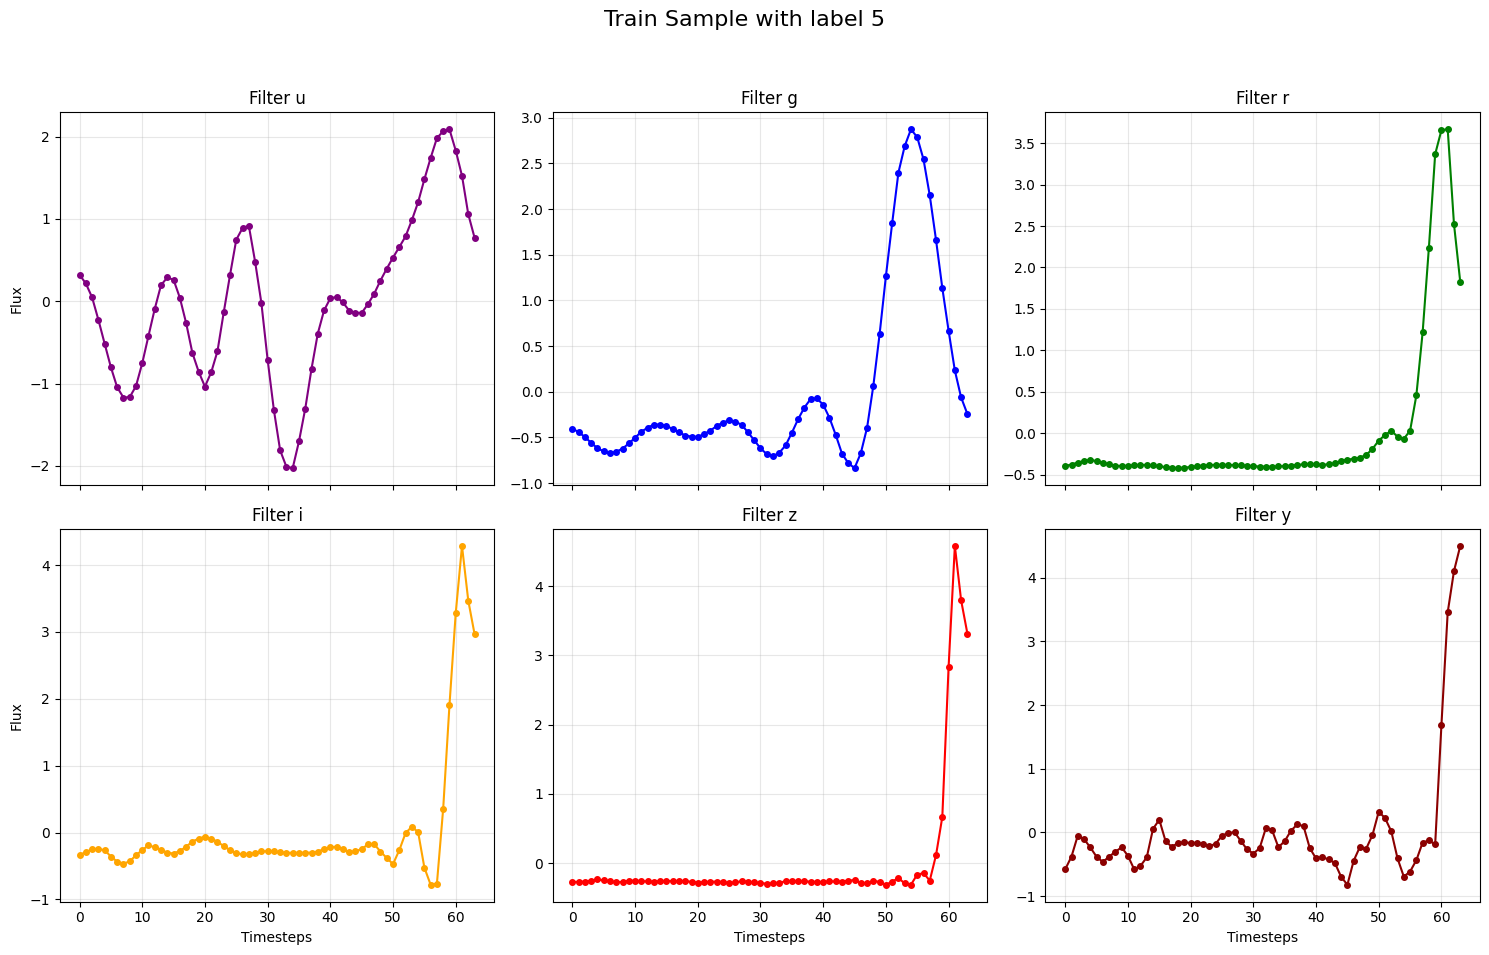

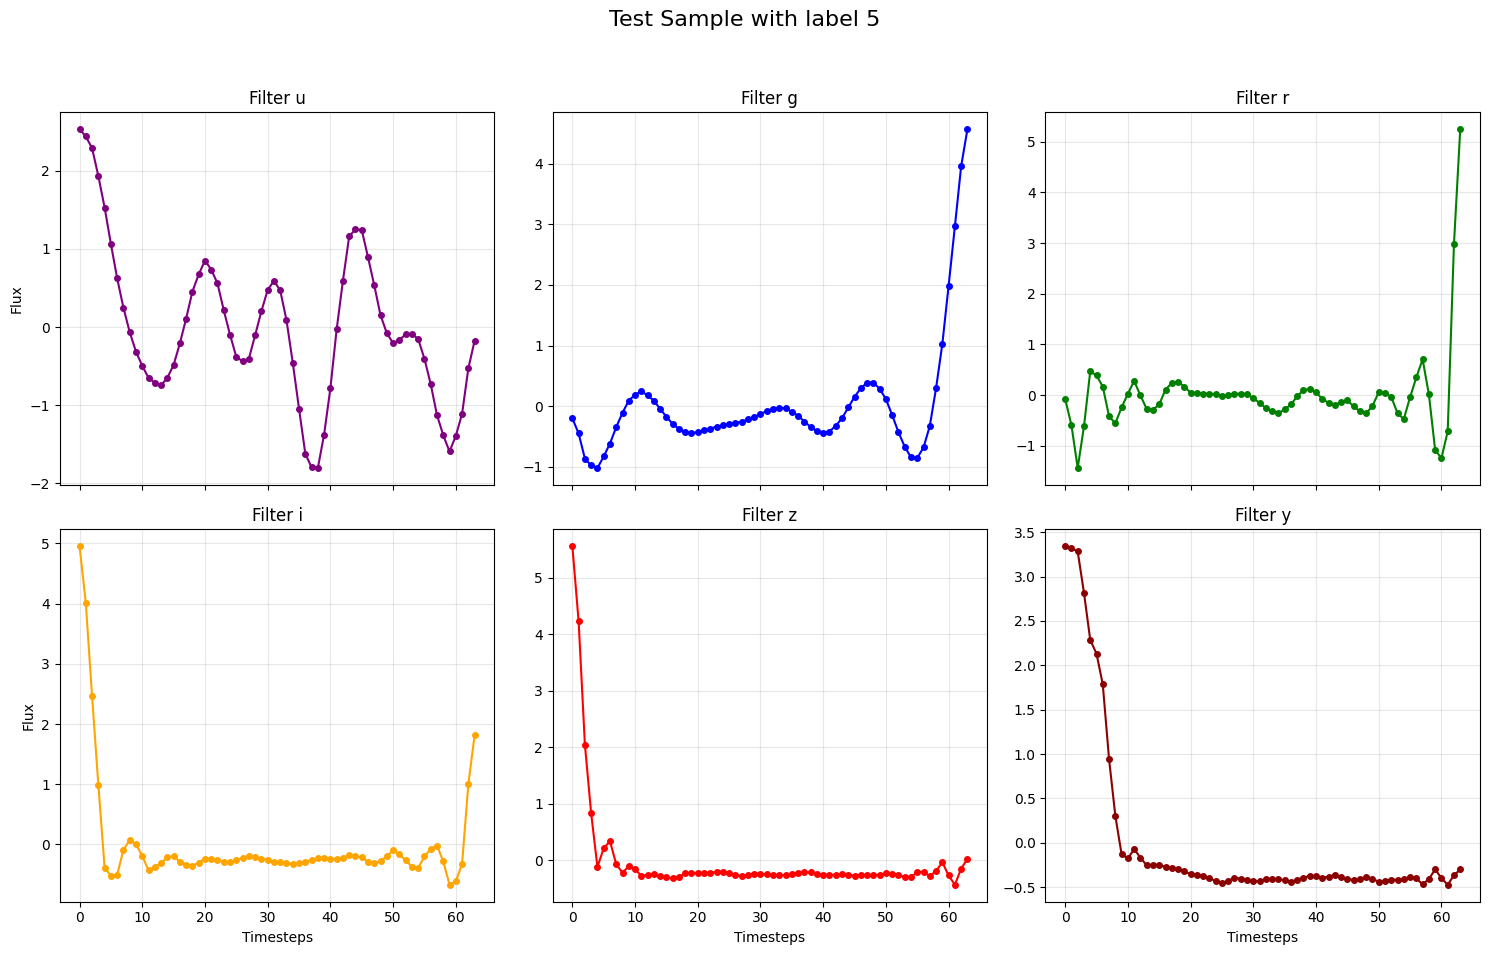

In [28]:
plot_lsst_channels(X_train.transpose(1,2), y_train, 0)

plot_lsst_channels(X_test.transpose(1,2), y_test, 0, False)

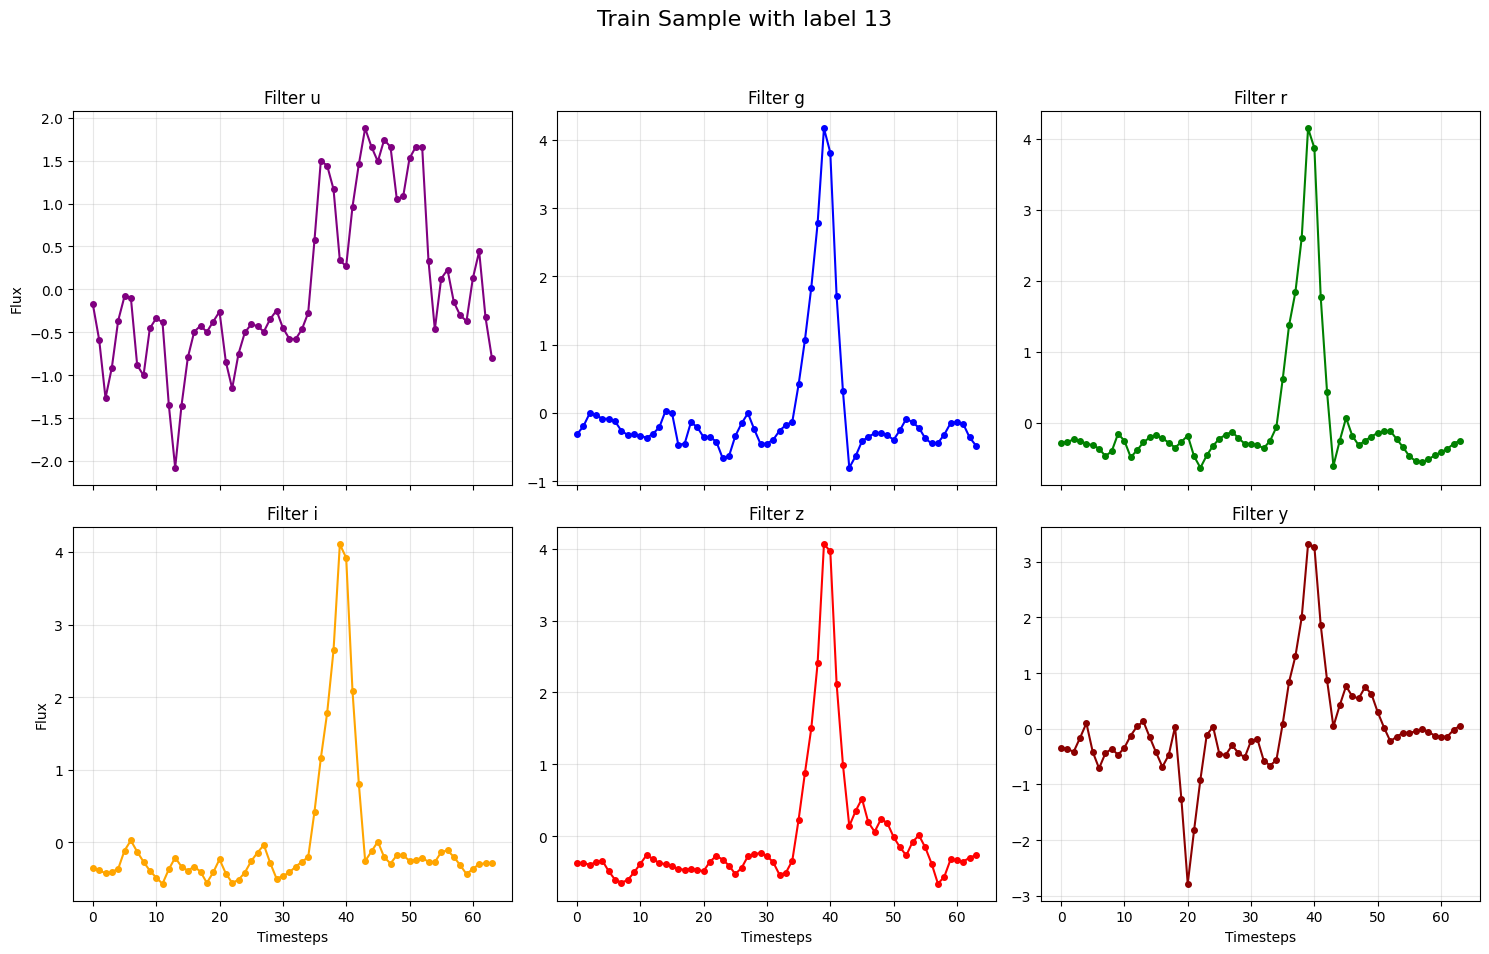

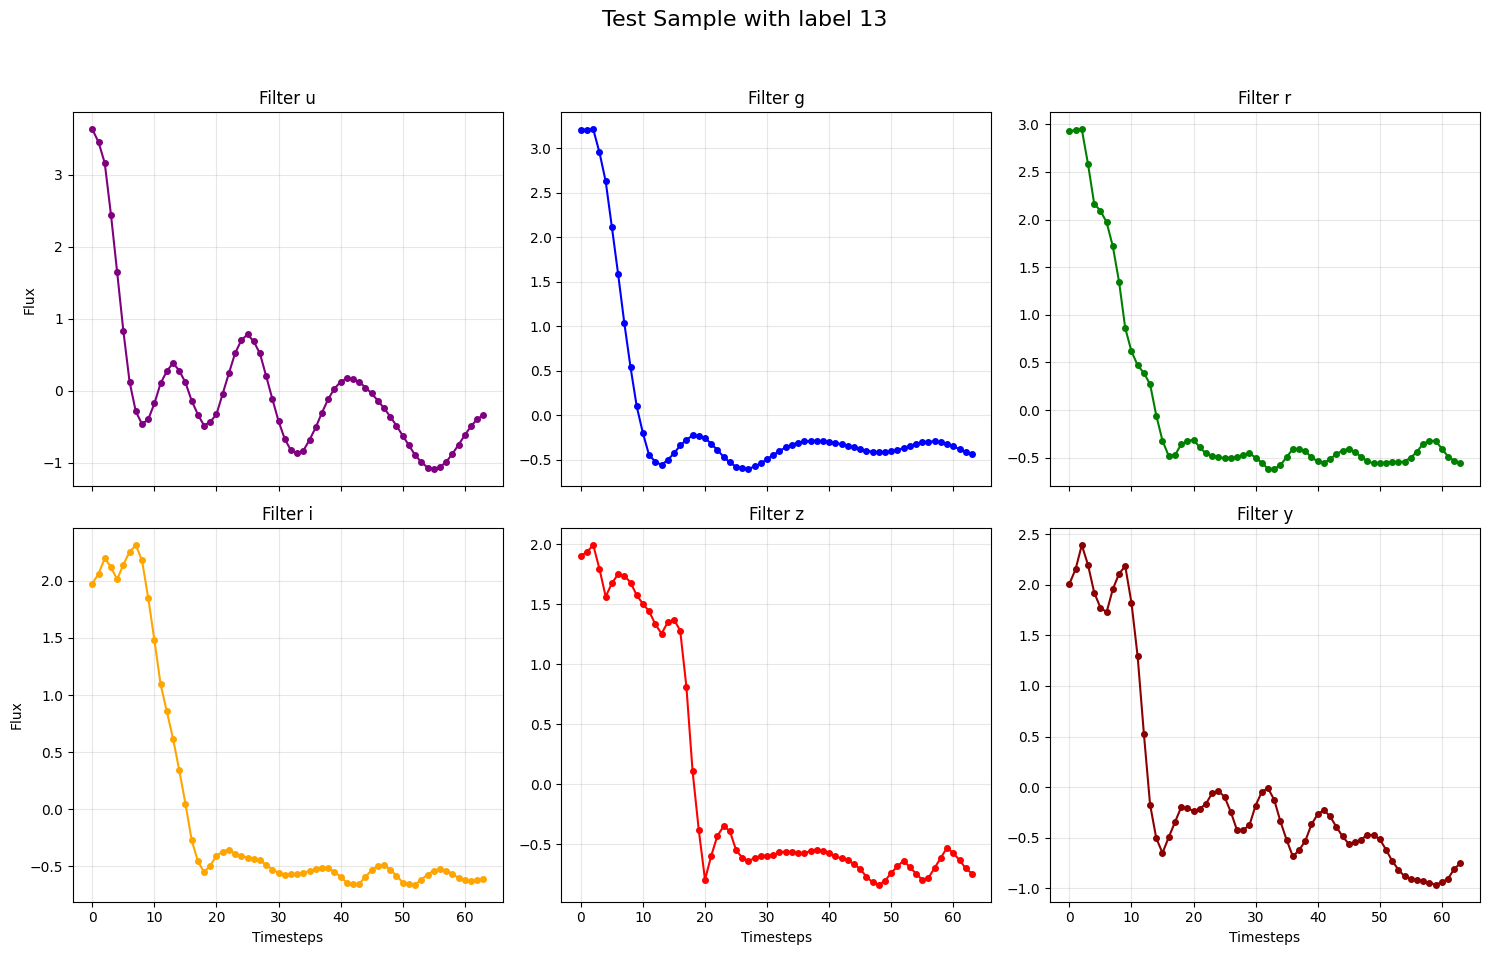

In [29]:
plot_lsst_channels(X_train.transpose(1,2), y_train, -1)

plot_lsst_channels(X_test.transpose(1,2), y_test, -1, False)